In [ ]:
import pandas as pd
import numpy as np

# Generate sample supermarket sales data
np.random.seed(42)

dates = pd.date_range("2023-01-01", periods=730, freq="D")

sales = (
    np.linspace(2000, 3500, 730)      # Trend
    + 200*np.sin(np.arange(730)*2*np.pi/30)  # Seasonality
    + np.random.normal(0, 100, 730)   # Noise
)

df = pd.DataFrame({
    "Date": dates,
    "Total": sales
})

print(df.head())


        Date        Total
0 2023-01-01  2049.671415
1 2023-01-02  2029.813521
2 2023-01-03  2150.231409
3 2023-01-04  2276.032876
4 2023-01-05  2133.444080


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df.head()


,Total
Date,
2023-01-01,2049.671415
2023-01-02,2029.813521
2023-01-03,2150.231409
2023-01-04,2276.032876
2023-01-05,2133.444080


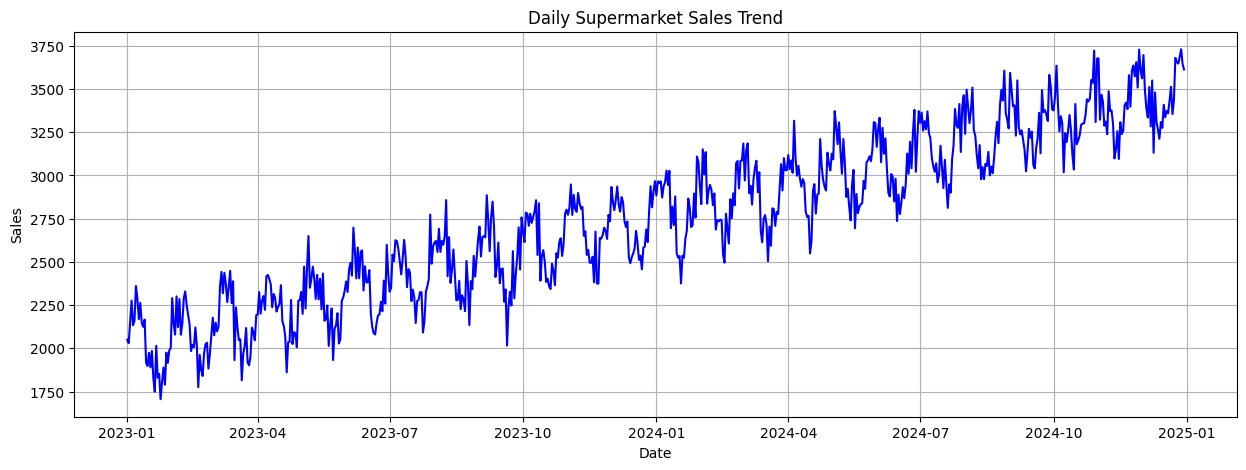

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df.index, df['Total'], color='blue')

plt.title("Daily Supermarket Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()


In [ ]:
df['MA7'] = df['Total'].rolling(window=7).mean()

df['MA30'] = df['Total'].rolling(window=30).mean()

df.head()


,Total,MA7,MA30
Date,,,
2023-01-01,2049.671415,NaN,NaN
2023-01-02,2029.813521,NaN,NaN
2023-01-03,2150.231409,NaN,NaN
2023-01-04,2276.032876,NaN,NaN
2023-01-05,2133.444080,NaN,NaN


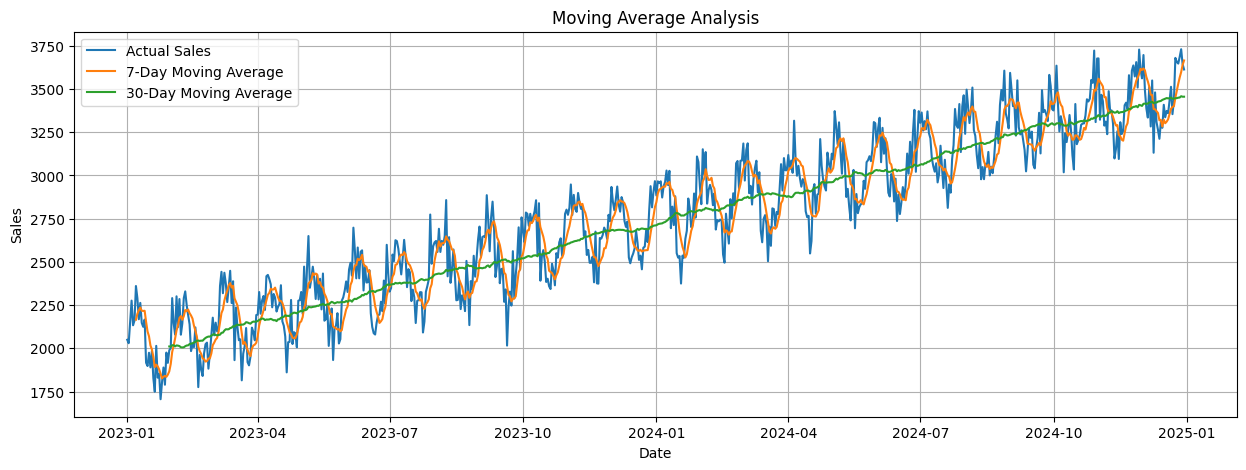

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df['Total'], label='Actual Sales')

plt.plot(df['MA7'], label='7-Day Moving Average')

plt.plot(df['MA30'], label='30-Day Moving Average')

plt.title("Moving Average Analysis")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()


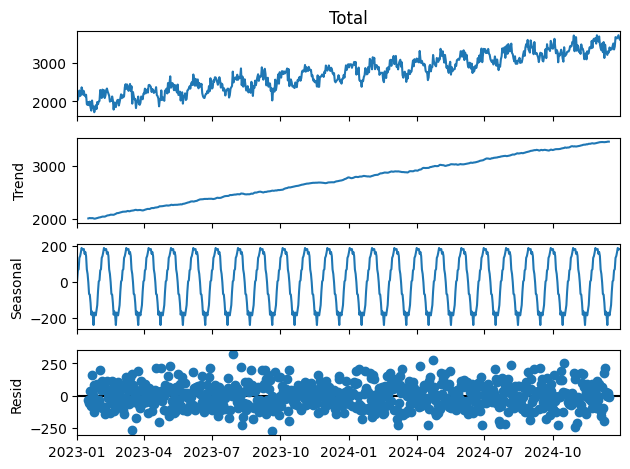

In [ ]:
decomposition = seasonal_decompose(
    df['Total'],
    model='additive',
    period=30
)

decomposition.plot()

plt.show()


In [ ]:
# Split the dataset into training and testing sets
train = df.iloc[:-30]

test = df.iloc[-30:]

print("Training Data:", train.shape)
print("Testing Data:", test.shape)


Training Data: (700, 3)
Testing Data: (30, 3)


In [ ]:
model = ARIMA(train['Total'], order=(2,1,2))

result = model.fit()

print(result.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Total   No. Observations:                  700
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -4372.390
Date:                Fri, 10 Jul 2026   AIC                           8754.781
Time:                        14:57:07   BIC                           8777.529
Sample:                    01-01-2023   HQIC                          8763.575
                         - 11-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9651      0.163     -5.918      0.000      -1.285      -0.645
ar.L2         -0.2940      0.076     -3.882      0.000      -0.442      -0.146
ma.L1          0.4472      0.166      2.699      0.0

In [ ]:
forecast = result.forecast(steps=30)
forecast


,predicted_mean
2024-12-01,3623.889999
2024-12-02,3649.315058
2024-12-03,3620.691571
2024-12-04,3640.839308
2024-12-05,3629.811778
2024-12-06,3634.529864
2024-12-07,3633.219129
2024-12-08,3633.096765
2024-12-09,3633.600268
2024-12-10,3633.150330


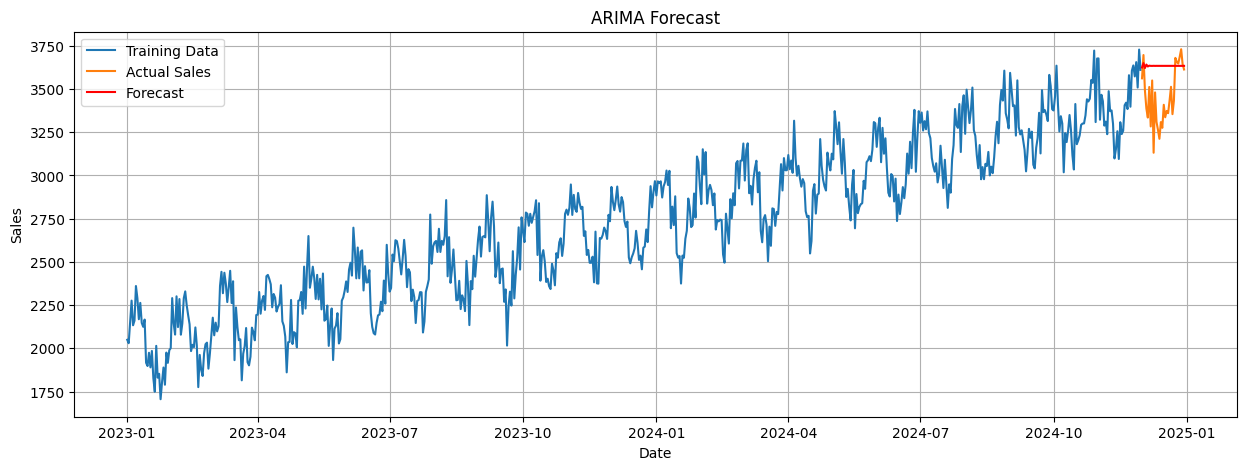

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(train.index,
         train['Total'],
         label='Training Data')

plt.plot(test.index,
         test['Total'],
         label='Actual Sales')

plt.plot(test.index,
         forecast,
         label='Forecast',
         color='red')

plt.title("ARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()


In [ ]:
rmse = np.sqrt(
    mean_squared_error(
        test['Total'],
        forecast
    )
)

print("RMSE =", rmse )


RMSE = 239.47942900806714
